# Chapter 57 - Deep Learning for Sequential Strain Data
### *Modern Strain Gage Technology* - Companion Notebook

The chapter's sequence example forecasts **stiffness loss in fatigue** from a strain-gage record. The data are
the NASA Ames / Stanford **CFRP Composites** set (Saxena, Goebel, Larrosa and Chang, NASA Prognostics Data
Repository), the same coupons as Chapter 55. During each fatigue block the test machine logged the 0° gage of
three rosettes (near the actuator strip, at mid-length, level with the notch, near the sensor strip) at about 46
samples per second while the coupon cycled at 5 Hz under constant load amplitude. Under constant load
amplitude the strain range is inversely proportional to stiffness, so the record is a stiffness history.

The notebook:

1. turns every 50 cycles of the mid-length gage into a strain range and a normalized stiffness (Eq. 57.1);
2. reports which gages survived the test;
3. forecasts stiffness 1,000 and 10,000 cycles ahead with three models - **persistence** (no change),
   a **local trend** (a straight line in log cycles through the last 10,000 cycles) and a small **GRU** trained
   on the other coupons - and scores each against persistence (Eq. 57.2).

Figure produced: `fig57_nb1_stiffness_forecast.png` (Figure 57.1), 300 dpi, into `src/media/ch57/`.

**Data.** 4.6 GB archive, not stored in the repository: put it in `notebooks/data/cfrp/` (git-ignored), point
`MSGT_CFRP_DIR` at it, or set `DOWNLOAD = True`. Only the small strain files are read; the first run takes about
a minute, the GRU training (CPU, five seeds, three folds, two horizons) a few minutes. The repository asks
users to acknowledge it and the data donors; NASA and the donors assume no liability for use of the data.

In [1]:
# !pip install numpy scipy pandas matplotlib scikit-learn openpyxl torch
import os, io, re, zipfile, urllib.request, pathlib, warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import openpyxl
import matplotlib.pyplot as plt
import torch
from torch import nn
from scipy.signal import find_peaks
from sklearn.metrics import r2_score
%matplotlib inline
warnings.filterwarnings('ignore')

OUT_DIR = pathlib.Path('../src/media/ch57'); OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 10.5, 'axes.titlesize': 10.5, 'legend.fontsize': 9.8})   # drawn 7.5 in wide, printed at 6.25 in
STEEL, COPPER, GREEN, GRAY = '#3b6ea5', '#c8631b', '#2e8b57', '0.55'
NL = chr(10)
torch.set_num_threads(4)

In [2]:
# ---- CFRP data access (shared by the Ch 55 and Ch 57 notebooks) ----
import os, io, re, zipfile, urllib.request, pathlib
import numpy as np, pandas as pd, scipy.io as sio

DATA_URL = "https://phm-datasets.s3.amazonaws.com/NASA/2.+Composites.zip"   # 4.6 GB
CFRP_DIR = pathlib.Path(os.environ.get("MSGT_CFRP_DIR", "data/cfrp")).expanduser()
DOWNLOAD = False   # set True to fetch the 4.6 GB archive automatically (one time)


def layup_zip(L):
    """Return an open ZipFile for Layup L (1-3), unpacking it from the archive if needed."""
    p = CFRP_DIR / f"Layup{L}.zip"
    if not p.exists():
        outer = CFRP_DIR / "Composites.zip"
        if not outer.exists():
            if not DOWNLOAD:
                raise FileNotFoundError(
                    f"CFRP data not found in {CFRP_DIR.resolve()}.\n"
                    f"Download {DATA_URL} (4.6 GB) into that folder, or set DOWNLOAD = True,\n"
                    "or point the MSGT_CFRP_DIR environment variable at an existing copy.")
            CFRP_DIR.mkdir(parents=True, exist_ok=True)
            print("downloading", DATA_URL, "(4.6 GB) ...")
            urllib.request.urlretrieve(DATA_URL, outer)
        with zipfile.ZipFile(outer) as z, z.open(f"2. Composites/Layup{L}.zip") as s, open(p, "wb") as o:
            while chunk := s.read(1 << 24):
                o.write(chunk)
    return zipfile.ZipFile(p)

---
## 1 - From strain range to stiffness

The logbook in each coupon folder lists, for every fatigue block, the cycle count at which it started, the
mean load, and the name of the strain file recorded during it. Each 50-cycle window of the mid-length gage is
fitted with a sinusoid at the cycling frequency (least squares; the sampling gives only about nine points per
cycle, so a fit beats picking peaks). With the load amplitude fixed, the normalized stiffness is

$$S_n = \frac{E_n}{E_0} = \frac{\Delta\varepsilon_0 / P_0}{\Delta\varepsilon_n / P_n} \qquad (57.1)$$

where $\Delta\varepsilon$ is the fitted strain range and $P$ the logged mean load (the load ratio is constant,
so the range is proportional to the mean). The reference $\Delta\varepsilon_0$ is the median over the first
1,000 cycles of fatigue, after the static proof loading at the start of each test.

In [3]:
WIN = 50                      # cycles per stiffness estimate
CACHE = CFRP_DIR / 'derived' / 'ch57_strain_windows.csv'
GAGED = {'L1_S11_F': 1, 'L1_S12_F': 1, 'L2_S11_F': 2, 'L3_S11_F': 3, 'L3_S13_F': 3, 'L3_S14_F': 3}


def logbook(z, folder):
    name = next(n for n in z.namelist() if n.startswith(folder + '/') and n.endswith('.xlsx') and '/._' not in n)
    ws = openpyxl.load_workbook(io.BytesIO(z.read(name)), data_only=True).worksheets[0]
    rows = list(ws.iter_rows(values_only=True))
    h = next(i for i, r in enumerate(rows) if r and r[0] == 'Date')
    hdr = [str(c).strip() if c else '' for c in rows[h]]
    return pd.DataFrame([dict(zip(hdr, r)) for r in rows[h + 1:]]).rename(columns={'Load [kips]': 'Load'})


def sine_fit(x, spc):
    n = np.arange(len(x)); w = 2 * np.pi / spc
    A = np.column_stack([np.sin(w * n), np.cos(w * n), np.ones(len(n))])
    c, *_ = np.linalg.lstsq(A, x, rcond=None)
    return 2 * np.hypot(c[0], c[1]), (x - A @ c).std()     # peak-to-peak range, fit residual


def block_windows(X):
    # X: (n, 3) microstrain, gages at actuator (A), middle (M), sensor (S) positions
    ref = X[:, 1] if np.ptp(X[:, 1]) > 500 else X[:, 0]
    p, _ = find_peaks(ref, distance=5, prominence=0.4 * (np.percentile(ref, 99) - np.percentile(ref, 1)))
    out = []
    for i in range(0, len(p) - WIN, WIN):
        a, b = p[i], p[i + WIN]
        spc = (b - a) / WIN
        if not 7 < spc < 12:
            continue
        r = {'cyc_in_block': i + WIN / 2}
        for ch, pos in enumerate('AMS'):
            r['range_' + pos], r['resid_' + pos] = sine_fit(X[a:b, ch], spc)
        out.append(r)
    return out


if not CACHE.exists():
    recs = []
    for folder, L in GAGED.items():
        z = layup_zip(L)
        lb = logbook(z, folder)
        for _, r in lb.iterrows():
            mts = r.get('MTS File Name')
            if not isinstance(mts, str):
                continue
            for tok in re.split(r'[ ,]+', mts.strip()):
                if 'STRAIN' in tok or not re.search(r'_F\d+$', tok):
                    continue                                   # cyclic blocks only, not the static ramps
                name = f'{folder}/StrainData/{tok}_DAT.mat'
                if name not in z.namelist():
                    continue
                m = sio.loadmat(io.BytesIO(z.read(name)), squeeze_me=True)
                X = np.column_stack([m['strain1'], m['strain2'], m['strain3']]) * 1e6
                for w in block_windows(X):
                    w.update(coupon=folder.replace('_F', '').replace('_', ''), file=tok,
                             cycle=float(r['Cycles']) + w.pop('cyc_in_block'), mean_load_kip=float(r['Load']))
                    recs.append(w)
        print(folder, 'done')
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(recs).to_csv(CACHE, index=False)

win = pd.read_csv(CACHE)
print(len(win), 'fifty-cycle windows')

14835 fifty-cycle windows


---
## 2 - Which gages survived?

A window is accepted when the mid-length gage gives a strain range between 1,000 and 9,000 µε with a sinusoid
residual under 400 µε. Saturated channels (the logbooks record several) and dead channels (zero output) fail
the test.

In [4]:
ok = (win.range_M > 1000) & (win.range_M < 9000) & (win.resid_M < 400)
health = win.assign(ok=ok).groupby('coupon').agg(windows=('ok', 'size'), valid=('ok', 'sum'),
                                                  last_cycle=('cycle', 'max'))
health['last_valid_cycle'] = win[ok].groupby('coupon').cycle.max()
print(health.fillna(0).astype(int))

# Usable records: the mid-length gage until it failed (cycle limits read from the table above)
LIMIT = {'L1S11': 175000, 'L1S12': 90000, 'L2S11': 70000}
BIN = 1000                                              # cycles per point of the stiffness series
series, starts = {}, {}
for c, lim in LIMIT.items():
    d = win[(win.coupon == c) & ok & (win.cycle <= lim)].copy()
    comp = d.range_M / d.mean_load_kip                  # compliance proxy, microstrain per kip
    d['S'] = comp[d.cycle < 1000].median() / comp       # Eq. 57.1
    s = d.groupby((d.cycle // BIN).astype(int)).S.median()
    series[c] = s.reindex(range(s.index.min(), s.index.max() + 1))
    starts[c] = sorted(set((d.groupby('file').cycle.min() // BIN).astype(int)))   # first bin of each block
    print(f"{c}: {s.notna().sum()} bins, stiffness at end {s.iloc[-3:].mean():.3f}, "
          f"loss {100 * (1 - s.iloc[-3:].mean()):.1f} %")

# The sawtooth: stiffness recovers at each restart after a stop
for c in LIMIT:
    v = series[c]
    jumps = [(b, 100 * (v.loc[b] - v.loc[b - 1])) for b in starts[c][1:]
             if b - 1 in v.index and not np.isnan(v.loc[b]) and not np.isnan(v.loc[b - 1])]
    print(c, 'stiffness change across each restart, % of E0:', [(b * BIN, round(j, 1)) for b, j in jumps])

        windows  valid  last_cycle  last_valid_cycle
coupon                                              
L1S11      4774   3485      271325            174925
L1S12      1777   1613       89975             89975
L2S11      3570   1394      206175             69975
L3S11      1077      1      103125                35
L3S13      1517      1      316825                45
L3S14      2120      1      218425                35
L1S11: 175 bins, stiffness at end 0.928, loss 7.2 %
L1S12: 81 bins, stiffness at end 0.936, loss 6.4 %
L2S11: 70 bins, stiffness at end 0.898, loss 10.2 %
L1S11 stiffness change across each restart, % of E0: [(1000, -0.1), (10000, 0.0), (20000, -0.5), (30000, -0.5), (40000, -0.0), (50000, 0.5), (60000, -0.6), (70000, 0.3), (80000, 1.0), (90000, -0.2), (100000, -0.5), (125000, 0.7), (150000, 0.1)]
L1S12 stiffness change across each restart, % of E0: [(1000, -1.2), (30000, -1.2), (40000, -0.3), (50000, -0.3), (60000, -0.1), (70000, 0.9), (80000, 0.0)]
L2S11 stiffness chan

---
## 3 - Forecasting stiffness, scored against persistence

At every 1,000-cycle bin from 10,000 cycles on, each model sees the last ten bins and forecasts the stiffness
`H` bins ahead. **Persistence** says it will equal the last bin. **Local trend** fits a straight
line to the last ten bins against log10(cycles) and extends it. The **GRU** (one layer, 16 units) reads the
last ten bins as a sequence (stiffness relative to the current value, and log cycles) and predicts the change from the last bin, so a GRU that has learned nothing is persistence;
it is trained only on the other two coupons, five random seeds averaged. The score is the mean absolute error
and the skill against persistence,

$$\mathrm{SS} = 1 - \frac{\mathrm{MAE}_{\text{model}}}{\mathrm{MAE}_{\text{persistence}}} \qquad (57.2)$$

which is zero for a model no better than "nothing changes" and negative for a worse one.

In [5]:
K = 10                                                  # history bins (10,000 cycles)


def origins(s, H):
    v, idx, out = s.values, s.index.values, []
    for i in range(K, len(v) - H):
        h = v[i - K + 1:i + 1]
        if np.isnan(h).sum() > 3 or np.isnan(v[i + H]) or np.isnan(v[i]):
            continue
        h = pd.Series(h).interpolate(limit_direction='both').values
        out.append((idx[i], h, v[i], v[i + H]))          # persistence = last value
    return out


def trend(h, n0, H):
    x = np.log10((np.arange(n0 - K + 1, n0 + 1) + 0.5) * BIN)
    w = np.polyfit(x, h, 1)
    return np.polyval(w, np.log10((n0 + H + 0.5) * BIN))


def encode(n0, h, now):
    ln = np.log10((np.arange(n0 - K + 1, n0 + 1) + 0.5) * BIN) / 6.0
    return np.column_stack([(h - now) * 20, ln])        # scaled so both inputs are of order one


class GRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=2, hidden_size=16, batch_first=True)
        self.head = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1]).squeeze(-1)


def train_gru(coupons, H, seed):
    X, Y = [], []
    for c in coupons:
        for n0, h, now, tgt in origins(series[c], H):
            X.append(encode(n0, h, now)); Y.append((tgt - now) * 20)
    X, Y = torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)
    torch.manual_seed(seed)
    m = GRU(); opt = torch.optim.Adam(m.parameters(), lr=3e-3, weight_decay=1e-4)
    for epoch in range(150):
        perm = torch.randperm(len(X))
        for b in range(0, len(perm), 64):
            i = perm[b:b + 64]
            opt.zero_grad(); loss = ((m(X[i]) - Y[i]) ** 2).mean(); loss.backward(); opt.step()
    return m.eval()


rows = []
for H in (1, 10):
    for test in LIMIT:
        nets = [train_gru([c for c in LIMIT if c != test], H, seed) for seed in range(5)]
        for n0, h, now, tgt in origins(series[test], H):
            x = torch.tensor(encode(n0, h, now)[None], dtype=torch.float32)
            with torch.no_grad():
                gru = now + np.mean([m(x).item() for m in nets]) / 20
            v = series[test]
            rows.append(dict(H=H, coupon=test, n0=n0, actual=tgt, persistence=now,
                             smooth3=np.nanmean(v.loc[n0 - 2:n0].values),      # a lagging 'persistence'
                             trend=trend(h, n0, H), gru=gru,
                             crosses_restart=any(n0 < b <= n0 + H for b in starts[test])))
fc = pd.DataFrame(rows)

summary = []
for (H, c), d in list(fc.groupby(['H', 'coupon'])) + [((H, 'all'), d) for H, d in fc.groupby('H')]:
    mae_p = np.abs(d.persistence - d.actual).mean()
    for k in ('persistence', 'smooth3', 'trend', 'gru'):
        mae = np.abs(d[k] - d.actual).mean()
        summary.append(dict(horizon_cycles=H * BIN, coupon=c, model=k, n=len(d), MAE_pct=100 * mae,
                            R2=r2_score(d.actual, d[k]), skill=1 - mae / mae_p))
summary = pd.DataFrame(summary)
print(summary.round(3).to_string(index=False))

# GRU skill measured against the lagging three-point mean (the trap)
for H, d in fc.groupby('H'):
    m3 = np.abs(d.smooth3 - d.actual).mean()
    print(f'H = {H * BIN} cycles: GRU skill against a three-point-mean baseline {1 - np.abs(d.gru - d.actual).mean() / m3:+.2f}')
# Forecasts whose target lies across a restart
for H, d in fc.groupby('H'):
    for flag, dd in d.groupby('crosses_restart'):
        mp = np.abs(dd.persistence - dd.actual).mean()
        print(f'H = {H * BIN}: crosses restart = {flag}: n = {len(dd)}, persistence MAE {100 * mp:.2f} %, '
              f'GRU skill {1 - np.abs(dd.gru - dd.actual).mean() / mp:+.2f}')

 horizon_cycles coupon       model   n  MAE_pct     R2  skill
           1000  L1S11 persistence 164    0.088  0.976  0.000
           1000  L1S11     smooth3 164    0.152  0.954 -0.730
           1000  L1S11       trend 164    0.171  0.951 -0.948
           1000  L1S11         gru 164    0.106  0.974 -0.208
           1000  L1S12 persistence  63    0.101  0.942  0.000
           1000  L1S12     smooth3  63    0.178  0.885 -0.768
           1000  L1S12       trend  63    0.191  0.891 -0.891
           1000  L1S12         gru  63    0.095  0.944  0.056
           1000  L2S11 persistence  59    0.286  0.952  0.000
           1000  L2S11     smooth3  59    0.405  0.907 -0.416
           1000  L2S11       trend  59    0.327  0.927 -0.143
           1000  L2S11         gru  59    0.235  0.958  0.178
          10000  L1S11 persistence 155    0.582  0.117  0.000
          10000  L1S11     smooth3 155    0.625  0.004 -0.074
          10000  L1S11       trend 155    0.721 -0.187 -0.238
        

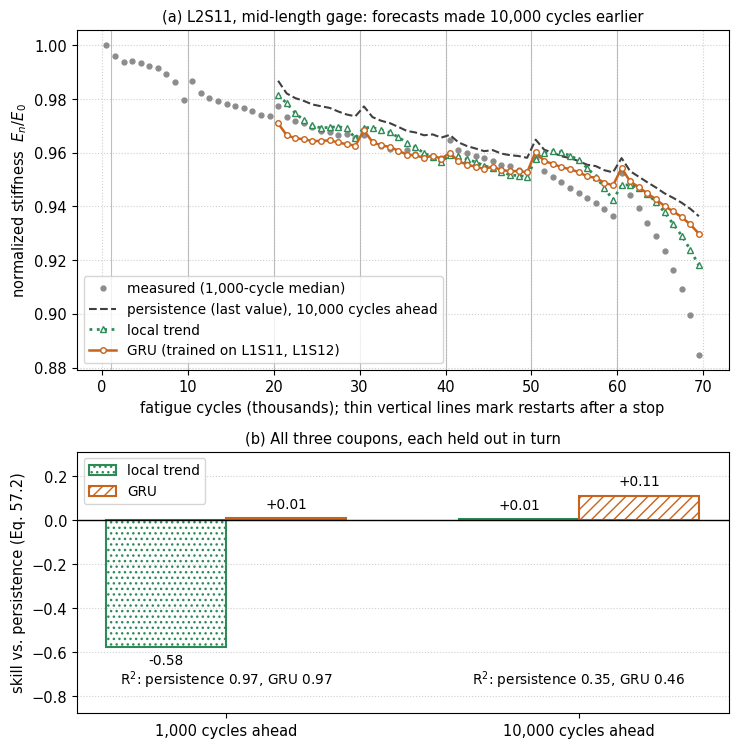

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.5, 7.6), gridspec_kw={'height_ratios': [1.3, 1]})
s = series['L2S11']
a1.plot((s.index + 0.5), s.values, 'o', color=GRAY, ms=3.5, label='measured (1,000-cycle median)')
for b in starts['L2S11'][1:]:
    a1.axvline(b, color='0.75', lw=0.8, ls='-', zorder=0)
d = fc[(fc.H == 10) & (fc.coupon == 'L2S11')]
tx = d.n0 + 10 + 0.5
a1.plot(tx, d.persistence, ls='--', color='0.25', lw=1.5, label='persistence (last value), 10,000 cycles ahead')
a1.plot(tx, d.trend, ls=':', color=GREEN, lw=2.0, marker='^', ms=4, mfc='white', label='local trend')
a1.plot(tx, d.gru, ls='-', color=COPPER, lw=1.8, marker='o', ms=4, mfc='white', label='GRU (trained on L1S11, L1S12)')
a1.set_xlabel('fatigue cycles (thousands); thin vertical lines mark restarts after a stop')
a1.set_ylabel('normalized stiffness  $E_n/E_0$')
a1.set_title('(a) L2S11, mid-length gage: forecasts made 10,000 cycles earlier')
a1.legend(loc='lower left'); a1.grid(True, ls=':', alpha=0.6)

al = summary[summary.coupon == 'all']
xs = np.arange(2); w = 0.34
vals = {}
for j, (k, hatch, col) in enumerate((('trend', '...', GREEN), ('gru', '///', COPPER))):
    v = [al[(al.horizon_cycles == H) & (al.model == k)].skill.item() for H in (1000, 10000)]
    vals[k] = v
    a2.bar(xs + (j - 0.5) * w, v, w, color='white', edgecolor=col, hatch=hatch, lw=1.5,
           label={'trend': 'local trend', 'gru': 'GRU'}[k])
    for xi, vi in zip(xs, v):
        a2.text(xi + (j - 0.5) * w, vi + (0.03 if vi >= 0 else -0.03), f'{vi:+.2f}', ha='center',
                va='bottom' if vi >= 0 else 'top', fontsize=9.8)
a2.axhline(0, color='black', lw=1)
lo = min(min(vals['trend']), min(vals['gru']))
hi = max(max(vals['trend']), max(vals['gru']))
a2.set_ylim(lo - 0.3, hi + 0.2)
for xi, H in zip(xs, (1000, 10000)):
    r2p = al[(al.horizon_cycles == H) & (al.model == 'persistence')].R2.item()
    r2g = al[(al.horizon_cycles == H) & (al.model == 'gru')].R2.item()
    a2.text(xi, lo - 0.1, f'R$^2$: persistence {r2p:.2f}, GRU {r2g:.2f}', ha='center', fontsize=9.8, va='top')
a2.set_xticks(xs); a2.set_xticklabels(['1,000 cycles ahead', '10,000 cycles ahead'])
a2.set_ylabel('skill vs. persistence (Eq. 57.2)')
a2.set_title('(b) All three coupons, each held out in turn'); a2.legend(loc='upper left'); a2.grid(True, axis='y', ls=':', alpha=0.6)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig57_nb1_stiffness_forecast.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## Where to take this next

1. **Add the coupons without strain gages.** Their raw MTS files (binary, 7 channels of 16-bit counts: load,
   extensometer, displacement, four strain channels) give load and crosshead displacement, hence a cruder
   stiffness history out to more than a million cycles. More sequences, and more that reach the late stage,
   are what a learned forecaster needs.
2. **Forecast the X-ray quantities.** The `DelaminationAreas.pdf` figure in the L1S19 folder plots measured
   delamination area against cycles for six coupons; pair it with the stiffness history and ask whether the
   strain record anticipates the delamination growth seen on the film.
3. **Try an LSTM or a small temporal convolution in place of the GRU,** and a longer history. With three
   coupons, expect differences between architectures to be smaller than the differences between seeds.